<a href="https://colab.research.google.com/github/Syamalatha11/Ai-learning-journey/blob/main/wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('winequality (1).csv')

# Display first 5 rows
print(df.head())

# Information about dataset
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

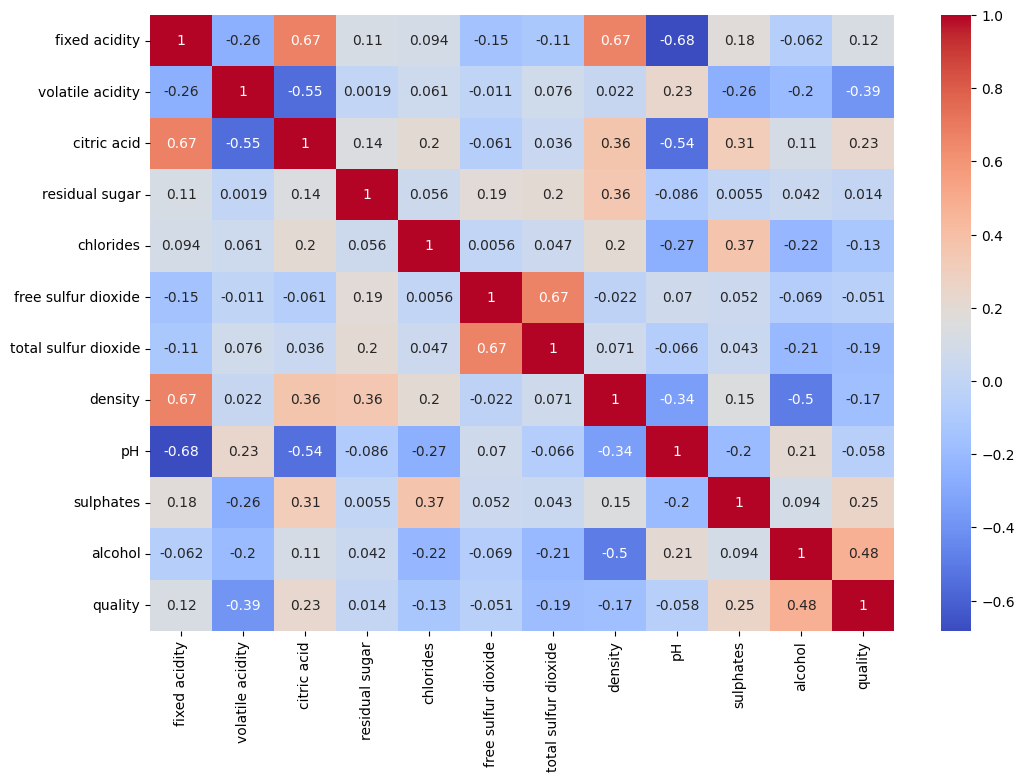

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

print(df.corr()['quality'].sort_values(ascending=False))

In [ ]:
df['quality_label'] = np.where(df['quality'] >= 7, 1, 0)

print(df[['quality', 'quality_label']].head())

print(df['quality_label'].value_counts())

   quality  quality_label
0        5              0
1        5              0
2        5              0
3        6              0
4        5              0
quality_label
0    1382
1     217
Name: count, dtype: int64


In [ ]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.89375
Precision: 0.7368421052631579
Recall: 0.32558139534883723
F1 Score: 0.45161290322580644
[[272   5]
 [ 29  14]]
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall:", recall_score(y_test, y_pred_scaled))
print("F1 Score:", f1_score(y_test, y_pred_scaled))

print(confusion_matrix(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.89375
Precision: 0.6956521739130435
Recall: 0.37209302325581395
F1 Score: 0.48484848484848486
[[270   7]
 [ 27  16]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



In [ ]:
# Logistic Regression
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [lr_acc, knn_acc, dt_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression   0.89375
1                  KNN   0.89375
2        Decision Tree   0.90000


In [ ]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [ ]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred))
print(confusion_matrix(y_test, best_pred))

Accuracy: 0.921875
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       277
           1       0.80      0.56      0.66        43

    accuracy                           0.92       320
   macro avg       0.87      0.77      0.81       320
weighted avg       0.92      0.92      0.92       320

[[271   6]
 [ 19  24]]


alcohol                 0.378178
sulphates               0.176199
volatile acidity        0.097446
total sulfur dioxide    0.096257
pH                      0.084223
residual sugar          0.074248
free sulfur dioxide     0.064605
citric acid             0.024723
chlorides               0.004121
fixed acidity           0.000000
density                 0.000000
dtype: float64


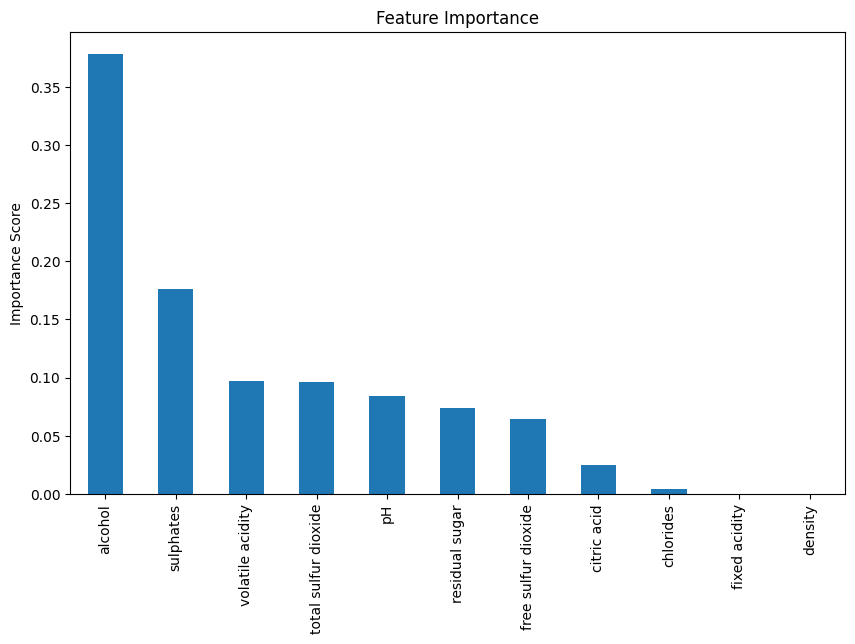

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.show()